# 3 · plot — Helico structure accuracy

Draws [`3_make_structure_accuracy_data.ipynb`](3_make_structure_accuracy_data.ipynb): one figure
per protein class, with **GDT-TS and lDDT side by side**.

**The two metrics are not on a common scale, and their numbers should not be subtracted from each
other.** GDT-TS superimposes the prediction on the reference and asks what fraction of residues
land within a set of distance cutoffs. lDDT never superimposes anything — it compares local
interatomic distances — so it credits locally correct geometry regardless of the global
arrangement, and it sits higher for the same structure. The `Helico, no contacts` arm makes the
point: **0.15 GDT-TS and 0.36 lDDT on the same predictions**. That 0.21 is the floor moving, not
the model doing better.

Read each metric within itself. Normalised between the no-contact floor and the oracle ceiling of
its own metric, MarinFold contacts get **45 %** of the way on GDT-TS and **51 %** on lDDT — the
two tell substantially the same story, which is worth knowing and is not what a raw comparison of
0.48 against 0.61 would suggest.

**The two protein classes do not say the same thing.** On natural monomers MarinFold's contacts
take Helico from far below the baselines to well above single-sequence Protenix-v2. On the 19
designed monomers they take it *down*, below `Helico, no contacts` — designed backbones are
idealised, single-sequence predictors already handle them, and imperfect contacts subtract. Any
caption over these panels has to survive that.

In [1]:
# Run from anywhere: figlib lives next to this notebook.
import sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "figlib.py").exists() else Path("notebooks/figures")
sys.path.insert(0, str(HERE.resolve()))
import figlib

In [2]:
DATASET = "3_structure_accuracy"
DPI = 300
# arm -> label, in the order the bars are drawn, top to bottom. `mf_L2` / `mf_L5` (the top-L/2 and
# top-L/5 contact budgets) are in the dataset and left out of the figure by default.
#
# The order is FIXED here rather than sorted by value. Every panel — both metrics, both protein
# classes — draws the same arms in the same places, so a reader compares a bar against its
# neighbour across panels instead of re-learning the axis each time. Sorting per panel would put
# an arm in a different row in each one, which is exactly when a reader stops comparing and
# starts guessing. Reorder by editing this dict.
ARMS = {
    "oracle": "Helico + true contacts",
    "mf_L": "Helico + MarinFold contacts",
    "off": "Helico, no contacts",
    "protenix_v2_single_seq": "Protenix-v2, single sequence",
    "esmfold2": "ESMFold2",
    "protenix_v2_msa": "Protenix-v2 + MSA",
}
HIGHLIGHT = "mf_L"
METRIC_LABELS = {"gdt_ts": "GDT-TS", "lddt": "lDDT", "tm_score": "TM-score", "rmsd": "RMSD (Å)"}
# Which proteins a panel is about, written inside the panel. A panel that travels into a figure
# without its caption should still say what it is measured on.
CLASS_LABELS = {"natural": "FoldBench natural monomers", "designed": "FoldBench de novo designs"}


#: Width of a panel that will sit two-up in a 6.5 in text column. Drawing at final size is what
#: keeps the type legible: the assembler scales a row to fit, so a panel drawn at 4.4 in is
#: shrunk to ~0.71 and its 8 pt tick labels land at 5.7 pt.
PANEL_WIDTH = 3.25


def label_protein_class(figure, protein_class):
    """Name the protein set at the panel's bottom-left, below the axes rather than inside them."""
    figure.text(0.005, 0.005, CLASS_LABELS.get(protein_class, protein_class),
                ha="left", va="bottom", fontsize=8, color="0.35")
metadata = figlib.describe(DATASET)

dataset      3_structure_accuracy
made by      3_make_structure_accuracy_data.ipynb
generated    2026-08-21T15:56:58+00:00
machine      ip1 · python 3.11.14 · NVIDIA RTX A5000 (23.7 GiB, cc 8.6)
checkout     4a01ffa3a27b on exp250/evals-exploration-notebook  ** UNCOMMITTED CHANGES **
packages     marinfold 0.1.0, torch 2.5.1+cu121, transformers 4.57.6, numpy 2.4.6, pandas 3.0.5, matplotlib 3.11.1

parameters
   metrics                  ['gdt_ts', 'lddt']
   classes                  ['natural', 'designed']
   bootstrap_draws          2000
   bootstrap_seed           0

inputs
   f79ea0842e9a        494,323 B  https://huggingface.co/buckets/timodonnell/helico-experiments/resolve/exp14_foldbench_held_out_monomers/scores/per_target.csv

outputs
   fc74c4789972          3,729 B  summary.csv
   e3a4a00280be        484,463 B  per_target.csv

note: this checkout is at a3e2e108a555, the dataset was made at 4a01ffa3a27b — regenerate if the difference touches the generator


--- designed · n=19 proteins ---


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/structure_accuracy_designed.{png,pdf,svg} (300 dpi)


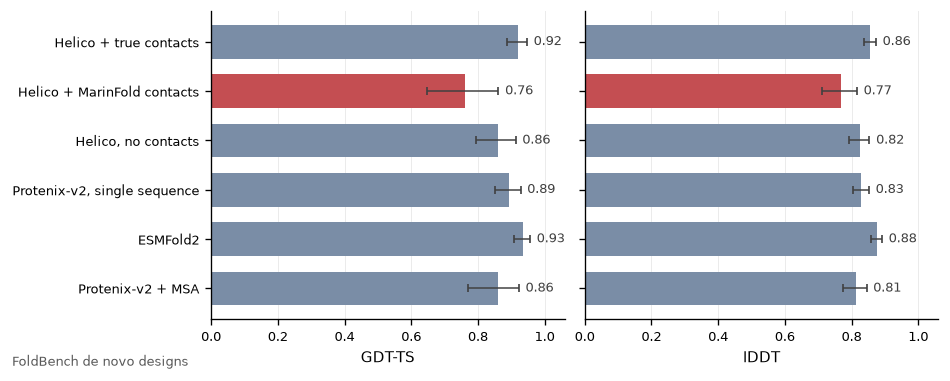

wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/gdt_ts_designed.{png,pdf,svg} (300 dpi)


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/lddt_designed.{png,pdf,svg} (300 dpi)
metric                        label  n  value  ci_low  ci_high
gdt_ts                     ESMFold2 19  0.934   0.908    0.956
gdt_ts       Helico + true contacts 19  0.920   0.886    0.947
gdt_ts Protenix-v2, single sequence 19  0.892   0.851    0.928
gdt_ts            Protenix-v2 + MSA 19  0.860   0.771    0.923
gdt_ts          Helico, no contacts 19  0.859   0.793    0.913
gdt_ts  Helico + MarinFold contacts 19  0.761   0.647    0.861
  lddt                     ESMFold2 19  0.876   0.859    0.891
  lddt       Helico + true contacts 19  0.856   0.837    0.873
  lddt Protenix-v2, single sequence 19  0.828   0.804    0.852
  lddt          Helico, no contacts 19  0.825   0.793    0.854
  lddt            Protenix-v2 + MSA 19  0.814   0.773    0.845
  lddt  Helico + MarinFold contacts 19  0.768   0.711    0.816
--- natural · n=305 proteins ---


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/structure_accuracy_natural.{png,pdf,svg} (300 dpi)


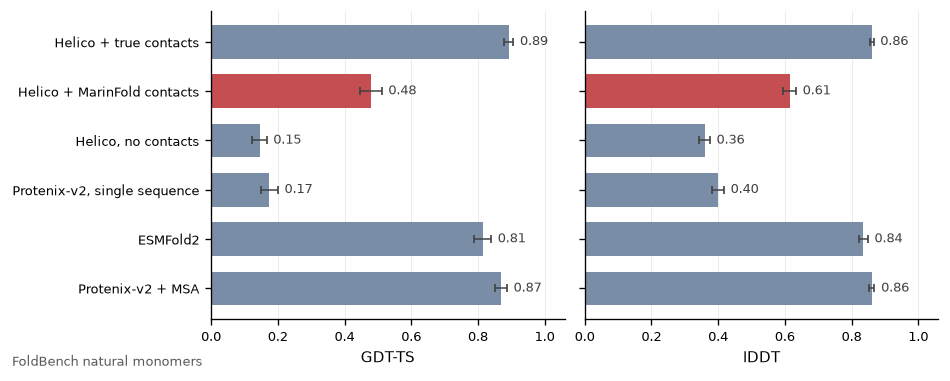

wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/gdt_ts_natural.{png,pdf,svg} (300 dpi)


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/notebooks/figures/output/lddt_natural.{png,pdf,svg} (300 dpi)
metric                        label   n  value  ci_low  ci_high
gdt_ts       Helico + true contacts 305  0.893   0.878    0.906
gdt_ts            Protenix-v2 + MSA 305  0.868   0.850    0.887
gdt_ts                     ESMFold2 305  0.814   0.787    0.839
gdt_ts  Helico + MarinFold contacts 305  0.479   0.445    0.511
gdt_ts Protenix-v2, single sequence 305  0.174   0.150    0.200
gdt_ts          Helico, no contacts 305  0.146   0.124    0.166
  lddt       Helico + true contacts 305  0.861   0.856    0.866
  lddt            Protenix-v2 + MSA 305  0.861   0.852    0.869
  lddt                     ESMFold2 305  0.835   0.821    0.849
  lddt  Helico + MarinFold contacts 305  0.615   0.595    0.633
  lddt Protenix-v2, single sequence 305  0.399   0.382    0.417
  lddt          Helico, no contacts 305  0.359   0.344    0.375


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

figlib.figure_style(DPI)
summary = pd.read_csv(figlib.require(DATASET, "summary.csv") / "summary.csv")
summary = summary[summary.arm.isin(ARMS)]
metrics = [m for m in metadata["metrics"]["names"] if m in set(summary.metric)]
ACCENT, NEUTRAL = "#C44E52", "#7A8DA6"

for protein_class in summary.protein_class.unique():
    frame = summary[summary.protein_class == protein_class]
    # barh draws the first row at the bottom, so reverse to read ARMS top to bottom.
    order = [arm for arm in reversed(list(ARMS)) if arm in set(frame.arm)]
    figure, axes = plt.subplots(1, len(metrics), figsize=(3.9 * len(metrics),
                                                          0.34 * len(order) + 1.0),
                                sharey=True, layout="constrained")
    axes = list(axes) if len(metrics) > 1 else [axes]
    for axis, metric in zip(axes, metrics):
        panel = frame[frame.metric == metric].set_index("arm").reindex(order)
        axis.barh([ARMS[arm] for arm in order], panel.value, height=0.68,
                  color=[ACCENT if arm == HIGHLIGHT else NEUTRAL for arm in order],
                  xerr=[panel.value - panel.ci_low, panel.ci_high - panel.value],
                  error_kw=dict(ecolor="0.25", lw=0.9, capsize=2.5))
        for y, row in enumerate(panel.itertuples()):
            axis.text(row.ci_high + 0.02, y, f"{row.value:.2f}", va="center", fontsize=7.5,
                      color="0.25")
        axis.set(xlabel=METRIC_LABELS.get(metric, metric), xlim=(0, 1.06))
        axis.grid(axis="x", alpha=0.25, lw=0.6)
        axis.set_axisbelow(True)
    label_protein_class(figure, protein_class)
    n = int(frame.n.iloc[0])
    print(f"--- {protein_class} · n={n} proteins ---")
    figlib.save_figure(figure, f"structure_accuracy_{protein_class}", DPI)
    plt.show()

    # One panel per metric as well: the manuscript's structure figure is GDT-TS alone, and a
    # single-metric panel is what can be dropped into it. Same data, same order, same colours.
    for metric in metrics:
        panel = frame[frame.metric == metric].set_index("arm").reindex(order)
        single, axis = plt.subplots(figsize=(PANEL_WIDTH, 0.34 * len(order) + 1.05),
                                    layout="constrained")
        axis.barh([ARMS[arm] for arm in order], panel.value, height=0.68,
                  color=[ACCENT if arm == HIGHLIGHT else NEUTRAL for arm in order],
                  xerr=[panel.value - panel.ci_low, panel.ci_high - panel.value],
                  error_kw=dict(ecolor="0.25", lw=0.9, capsize=2.5))
        for y, row in enumerate(panel.itertuples()):
            axis.text(row.ci_high + 0.02, y, f"{row.value:.2f}", va="center", fontsize=7.5,
                      color="0.25")
        axis.set(xlabel=METRIC_LABELS.get(metric, metric), xlim=(0, 1.06))
        axis.grid(axis="x", alpha=0.25, lw=0.6)
        axis.set_axisbelow(True)
        label_protein_class(single, protein_class)
        figlib.save_figure(single, f"{metric}_{protein_class}", DPI)
        plt.close(single)
    print(frame.assign(label=frame.arm.map(ARMS))[["metric", "label", "n", "value", "ci_low",
                                                   "ci_high"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3f}"))